# Binary Classification — Bank Customer Churn Prediction
**Dataset:** [Bank Customer Churn Dataset — Kaggle](https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction)

**Author:** Wisnu A. Pratama  
**Date:** 26 March 2026

---

## Objective
Predict whether a bank customer will leave (churn) based on their account and demographic information.
This is a **binary classification** problem — the target variable `Exited` is either 0 (stayed) or 1 (churned).

## Dataset Overview
- **Source:** Bank Customer Churn — Kaggle
- **Rows:** 10,000 customers
- **Features:** 11 features (mix of numerical and categorical)
- **Target:** `Exited` — 0 = stayed, 1 = churned
- **Class imbalance:** ~80% stayed, ~20% churned — important for evaluation strategy

## Key Concepts Covered
- Handling mixed data types (numerical + categorical)
- Label encoding for categorical features
- Class imbalance awareness and correct metric selection
- Five classifier comparison: KNN, Decision Tree, Random Forest, SVM, Naive Bayes
- Confusion matrix interpretation: TP, FP, FN, TN
- ROC-AUC curve and probability-based evaluation
- SHAP feature explainability

---

## Workflow
```
1. Setup & Data Download
2. Data Loading & Inspection
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train/Test Split
6. Model Training
7. Model Evaluation
8. Model Comparison & ROC Curves
9. SHAP Explainability
10. Conclusions & Recommendations
```

---
## 1. Setup & Data Download

### 1.1 Install & Import Libraries

In [1]:
# Core Libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)

# Explainability
import shap

# Additional Lib (if needed)
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully!")

All libraries imported successfully!


### 1.2 Download Dataset from Kaggle

**Prerequisites:** Kaggle API credentials must be set up.

**Step 1 — Install Kaggle CLI** (run once in terminal):
```bash
uv add kaggle
```

**Step 2 — Set up API credentials:**

First, you should have Kaggle Account to download the dataset.
1. Go to https://www.kaggle.com/settings
2. Scroll to **API** section → click **Create New Token**
3. Place the downloaded `kaggle.json` at:
   - Windows: `C:/Users/YOUR_USERNAME/.kaggle/kaggle.json`
   - Mac/Linux: `~/.kaggle/kaggle.json`

**Step 3 — Download the dataset:**

In [4]:
# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Download competition data using Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

def download_kaggle_dataset(dataset_identifier, download_path="./data"):
    """
    Downloads and unzips a standard dataset from Kaggle.
    Example identifier: 'shantanudhakadd/bank-customer-churn-prediction'
    """
    api = KaggleApi()
    api.authenticate()

    print(f"Downloading dataset: {dataset_identifier}...")
    
    # Ensure the directory exists (using a 'raw' folder is a Medallion architecture best practice)
    os.makedirs(download_path, exist_ok=True)
    
    # Download files (this downloads a .zip)
    api.dataset_download_files(dataset_identifier, path=download_path, quiet=False)
    
    # The zip file name is usually the second part of the identifier
    dataset_name = dataset_identifier.split('/')[1]
    zip_path = os.path.join(download_path, f"{dataset_name}.zip")
    
    # Unzip the downloaded file
    import zipfile
    if os.path.exists(zip_path):
        print("Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(download_path)
        os.remove(zip_path) # Clean up the zip file
        print(f"Success! Data saved to {download_path}")
    else:
        print("Error: Zip file not found after download.")

download_kaggle_dataset("shantanudhakadd/bank-customer-churn-prediction")

# Check downloaded file
print("Files in data/ folder:")
for f in os.listdir('data'):
    size = os.path.getsize(f'data/{f}') / (1024 * 1024)
    print(f"  {f} ({size:.1f} MB)")

Dataset URL: https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 262k/262k [00:00<00:00, 351kB/s]


Extracting files...
Success! Data saved to ./data
Files in data/ folder:
  Churn_Modelling.csv (0.7 MB)


---
## 2. Data Loading & Inspection

### 2.1 Load Data

In [5]:
# Load dataset
data = pd.read_csv('data/Churn_Modelling.csv')

print(f"Shape: {data.shape}")
data.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.0000,1,1,1,101348.8800,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.8600,1,0,1,112542.5800,0
2,3,15619304,Onio,502,France,Female,42,8,159660.8000,3,1,0,113931.5700,1
3,4,15701354,Boni,699,France,Female,39,1,0.0000,2,0,0,93826.6300,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.8200,1,1,1,79084.1000,0


### 2.2 Drop Irrelevant Columns

**Decision:** Drop `RowNumber`, `CustomerId`, and `Surname`.
**Reasoning:** These are identifiers — they carry no predictive signal and would only
introduce noise or cause the model to memorize IDs instead of learning patterns.

In [6]:
# Drop identifier columns — they add noise, not signal
data = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(f"Shape after dropping identifiers: {data.shape}")
print(f"Remaining columns: {list(data.columns)}")

Shape after dropping identifiers: (10000, 11)
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### 2.3 Data Inspection

In [7]:
# Data types and memory usage
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
data.info()

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [8]:
# Statistical summary
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
data.describe(include='all').round(4)

DESCRIPTIVE STATISTICS


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0000,10000,10000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.5288,NaN,NaN,38.9218,5.0128,76485.8893,1.5302,0.7055,0.5151,100090.2399,0.2037
std,96.6533,NaN,NaN,10.4878,2.8922,62397.4052,0.5817,0.4558,0.4998,57510.4928,0.4028
min,350.0000,NaN,NaN,18.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.5800,0.0000
25%,584.0000,NaN,NaN,32.0000,3.0000,0.0000,1.0000,0.0000,0.0000,51002.1100,0.0000
50%,652.0000,NaN,NaN,37.0000,5.0000,97198.5400,1.0000,1.0000,1.0000,100193.9150,0.0000
75%,718.0000,NaN,NaN,44.0000,7.0000,127644.2400,2.0000,1.0000,1.0000,149388.2475,0.0000


In [10]:
# Missing values check
missing = data.isnull().sum()
print("Missing Values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# Duplicate rows
print(f"Duplicate rows: {data.duplicated().sum()}")

# Target distribution
print(f"Target Distribution (Exited):")
print(data['Exited'].value_counts())
print(f"Churn Rate: {data['Exited'].mean()*100:.2f}%")

Missing Values:
No missing values found!
Duplicate rows: 0
Target Distribution (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.37%


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable — Class Imbalance Check

**This is critical for classification.** If classes are imbalanced (e.g., 80/20 split),
accuracy alone is misleading — a model that always predicts "stayed" would score 80%
accuracy without learning anything useful.

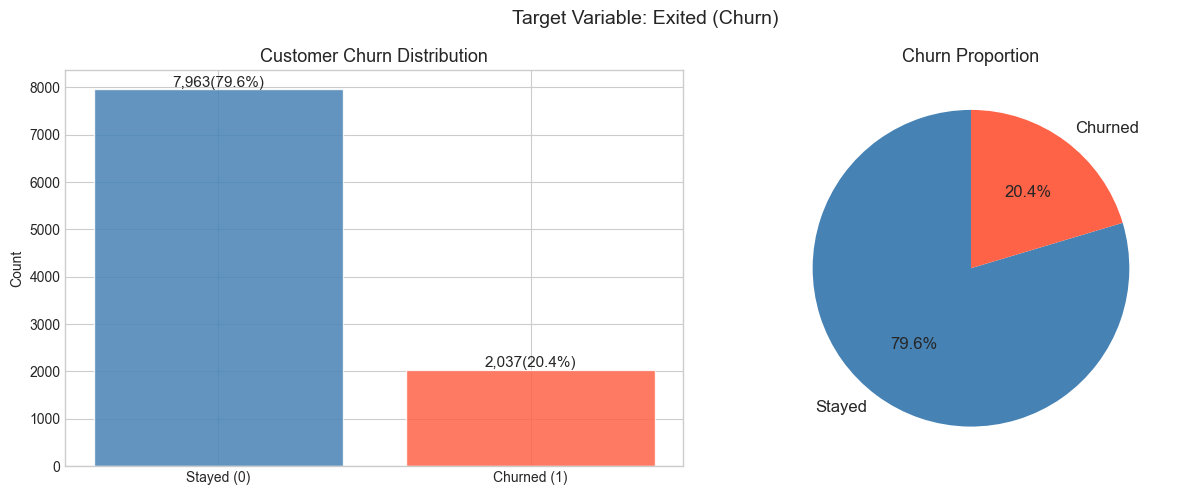

Key insight: Dataset has ~20% churn rate — class imbalance present.
This means Recall and F1-Score are more meaningful than Accuracy alone.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot
churn_counts = data['Exited'].value_counts()
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
axes[0].set_title('Customer Churn Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}({v/len(data)*100:.1f}%)',
                 ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Target Variable: Exited (Churn)', fontsize=14)
plt.tight_layout()
plt.savefig('data/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key insight: Dataset has ~20% churn rate — class imbalance present.")
print("This means Recall and F1-Score are more meaningful than Accuracy alone.")

### 3.2 Numerical Feature Distributions

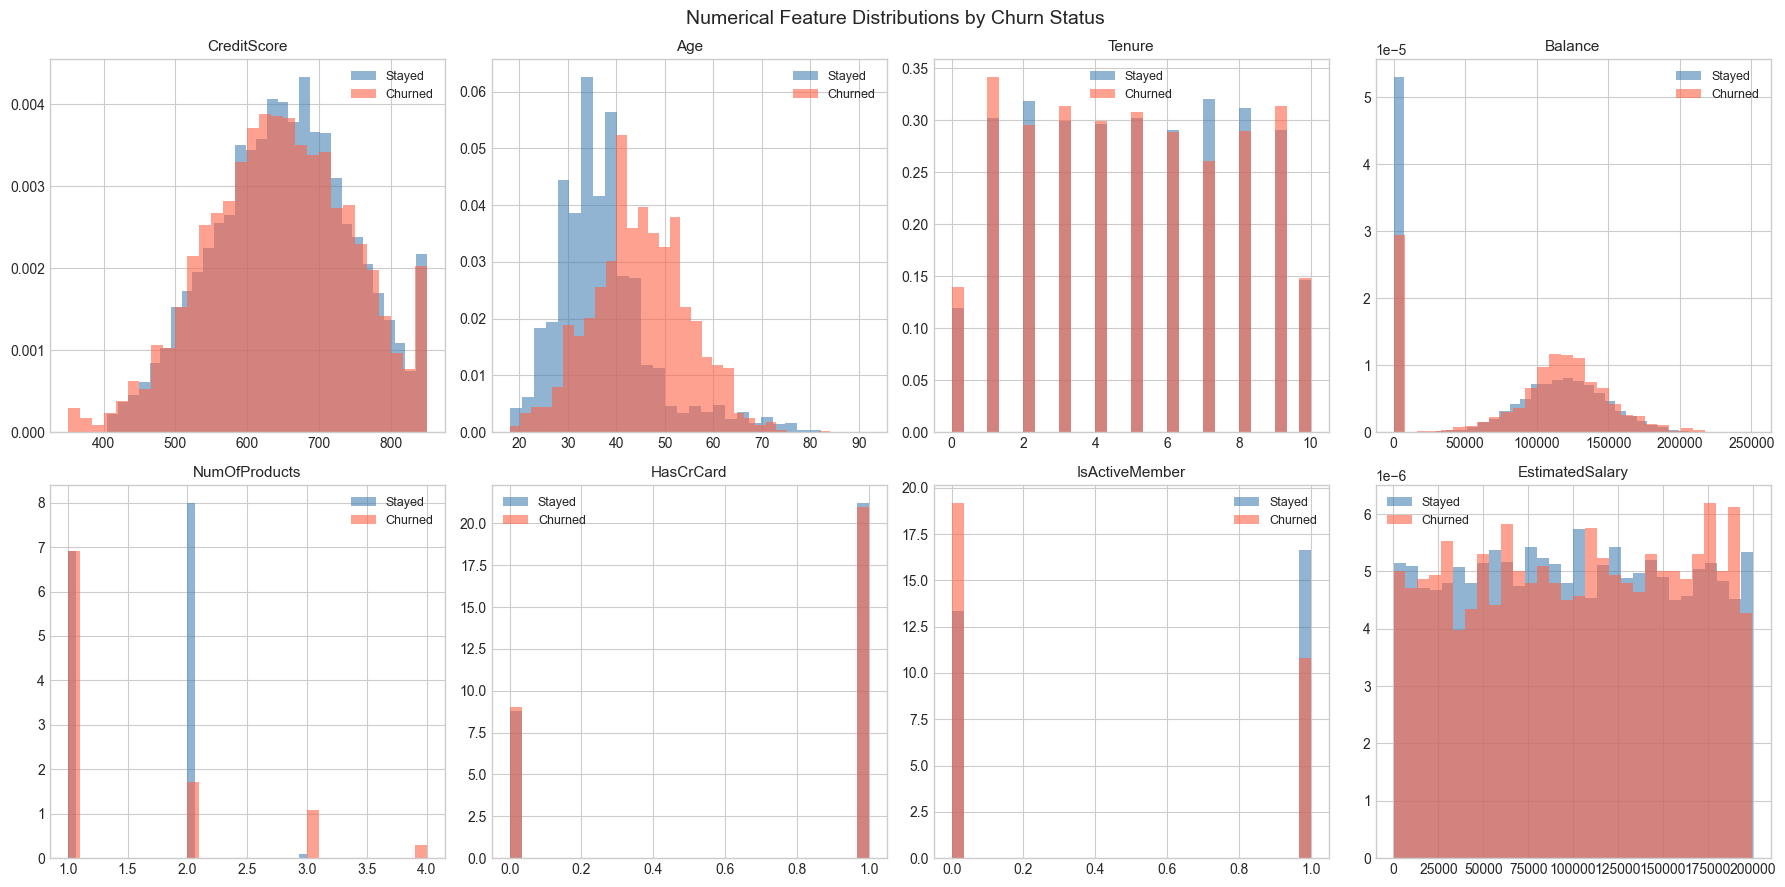

In [14]:
num_features = data.select_dtypes(include=[np.number]).columns.tolist()
num_features = [f for f in num_features if f != 'Exited']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Distributions split by churn status
    data[data['Exited']==0][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                       color='steelblue', label='Stayed', density=True)
    data[data['Exited']==1][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                       color='tomato', label='Churned', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14)
plt.tight_layout()
plt.savefig('data/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Categorical Feature Distributions

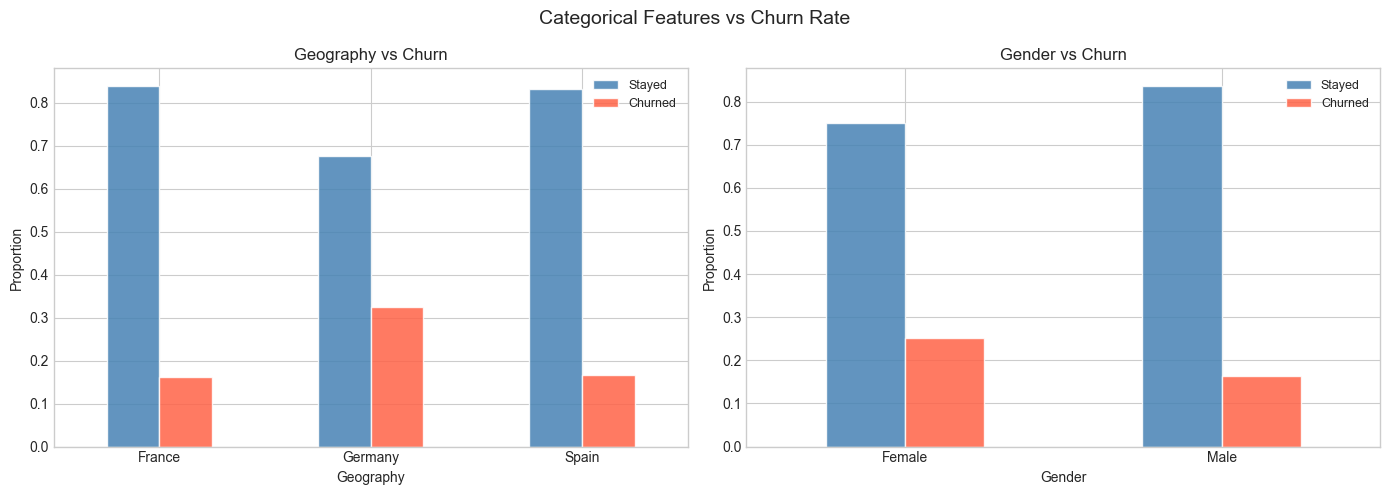

In [15]:
cat_features = data.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(1, len(cat_features), figsize=(14, 5))

for i, col in enumerate(cat_features):
    ct = data.groupby([col, 'Exited']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
                alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{col} vs Churn', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['Stayed', 'Churned'], fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Churn Rate', fontsize=14)
plt.tight_layout()
plt.savefig('data/categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Correlation Heatmap

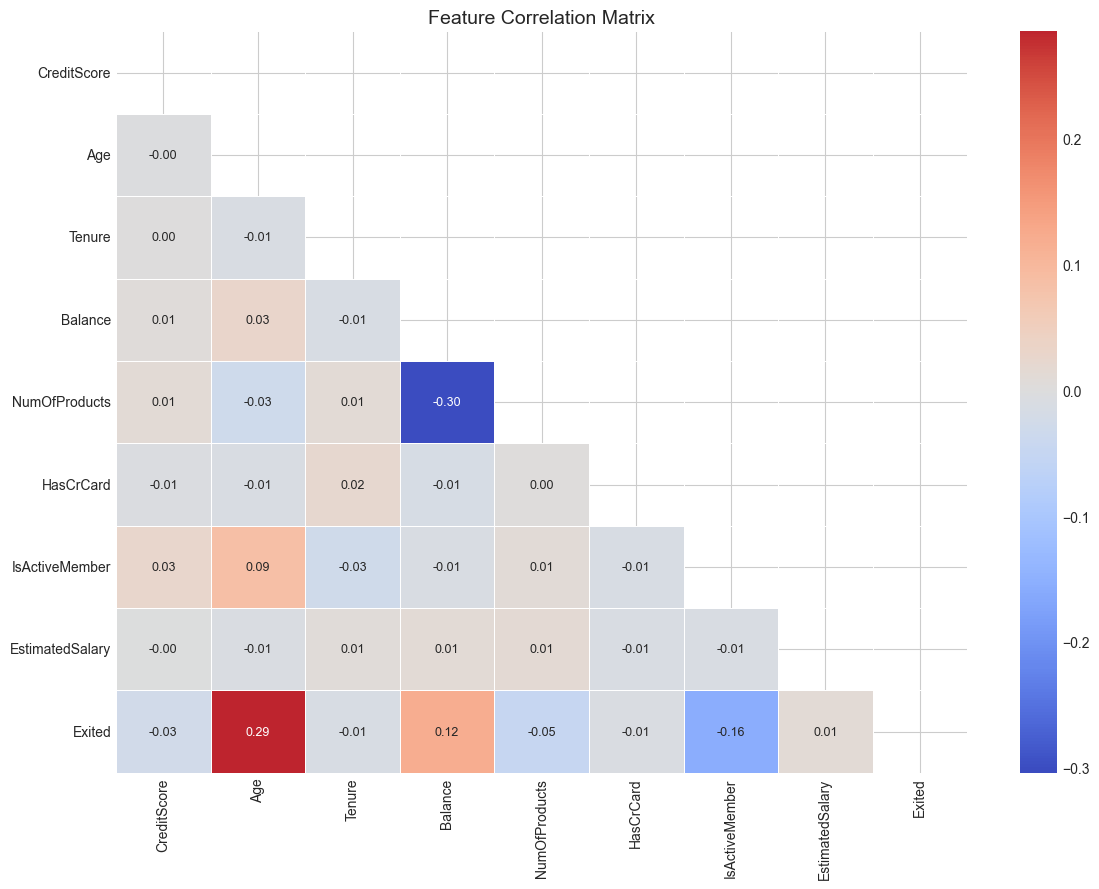

Feature correlations with Exited (churn):
Age                0.2853
IsActiveMember    -0.1561
Balance            0.1185
NumOfProducts     -0.0478
CreditScore       -0.0271
Tenure            -0.0140
EstimatedSalary    0.0121
HasCrCard         -0.0071
Name: Exited, dtype: float64


In [16]:
plt.figure(figsize=(12, 9))
corr = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target
target_corr = corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print("Feature correlations with Exited (churn):")
print(target_corr.round(4))

### 3.5 Boxplots — Numerical Features vs Churn

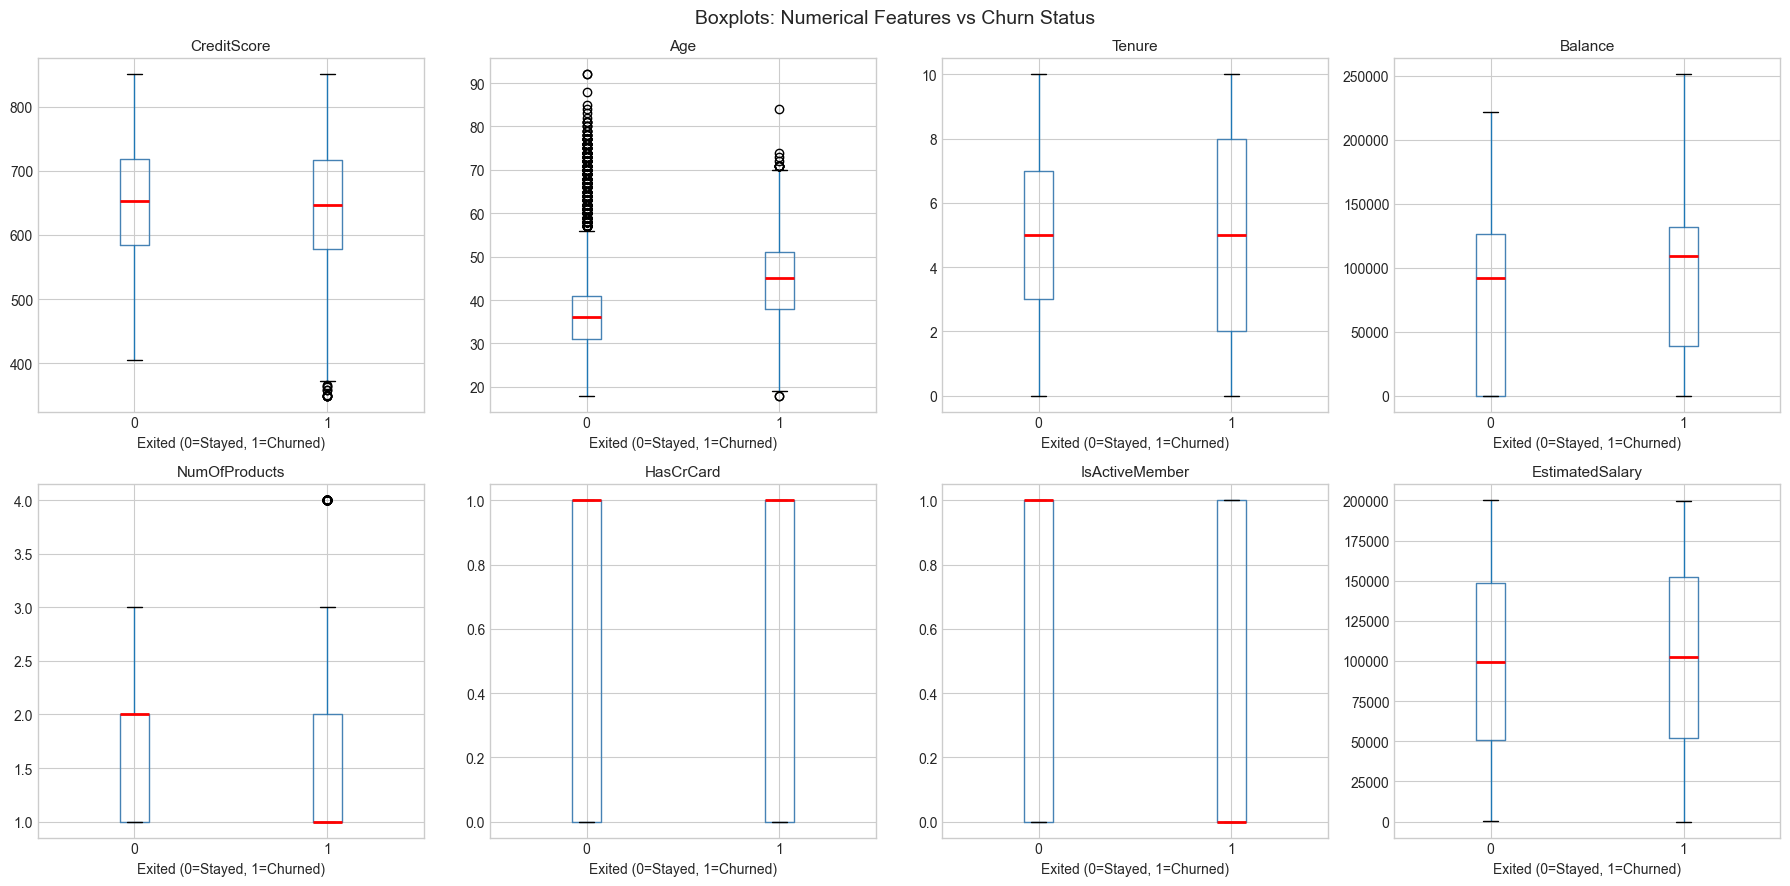

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data.boxplot(column=col, by='Exited', ax=axes[i],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Exited (0=Stayed, 1=Churned)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots: Numerical Features vs Churn Status', fontsize=14)
plt.tight_layout()
plt.savefig('data/boxplots_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Preprocessing

### 4.1 Label Encoding for Categorical Features

**Why Label Encoding here?**
- `Gender` has 2 values (Male/Female) — binary encoding is natural
- `Geography` has 3 values — Label Encoding is acceptable for tree-based models,
  but for distance-based models (KNN, SVM) we should use One-Hot Encoding

> **Best Practice Note:** For production code, use `OneHotEncoder` inside a `ColumnTransformer`
> pipeline to avoid ordinal assumptions in Geography. We use `LabelEncoder` here
> to match the original notebook's approach and keep it simple.

In [19]:
le = LabelEncoder()

categorical_cols = ['Geography', 'Gender']
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])
    print(f"{col} encoded: {dict(enumerate(le.classes_))}")

print("Data after encoding:")
data.head()

Geography encoded: {0: 'France', 1: 'Germany', 2: 'Spain'}
Gender encoded: {0: 'Female', 1: 'Male'}
Data after encoding:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.0000,1,1,1,101348.8800,1
1,608,2,0,41,1,83807.8600,1,0,1,112542.5800,0
2,502,0,0,42,8,159660.8000,3,1,0,113931.5700,1
3,699,0,0,39,1,0.0000,2,0,0,93826.6300,0
4,850,2,0,43,2,125510.8200,1,1,1,79084.1000,0


### 4.2 Feature Scaling — MinMaxScaler

**Why MinMaxScaler?** Scales all features to [0, 1] range.
Essential for distance-based algorithms (KNN, SVM) that are sensitive to feature magnitude.

> **Important:** Fit scaler on training data only (after split) to prevent data leakage.
> We apply it here for simplicity, but note this as a best practice improvement.

In [20]:
# Separate features and target BEFORE scaling
X = data.drop(columns=['Exited'])
y = data['Exited']

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"Feature columns: {list(X.columns)}")
print(f"\nClass distribution: {y.value_counts().to_dict()}")

Features (X): (10000, 10)
Target   (y): (10000,)
Feature columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Class distribution: {0: 7963, 1: 2037}


---
## 5. Train/Test Split

Using `stratify=y` to preserve class distribution in both train and test sets.
This is critical for imbalanced datasets — without stratify, one split might have
very few churned customers.

In [21]:
# Split first, then scale — correct order to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # preserve churn ratio in both splits
)

# Scale AFTER splitting — fit on train only
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — never fit on test

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"X_train: {X_train_scaled.shape} | Churn rate: {y_train.mean()*100:.1f}%")
print(f"X_test:  {X_test_scaled.shape}  | Churn rate: {y_test.mean()*100:.1f}%")

X_train: (8000, 10) | Churn rate: 20.4%
X_test:  (2000, 10)  | Churn rate: 20.3%


---
## 6. Model Training

Training 5 classifiers with default parameters first (baseline),
then we compare them and discuss what each algorithm does.

In [23]:
# Initialize all classifiers
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB()
}

# ── Train all models ──────────────────────────────────────────────────────────
print("Training all models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"  {name}: Done")

print("All models trained successfully!")

Training all models...
  KNN: Done
  Decision Tree: Done
  Random Forest: Done
  SVM: Done
  Naive Bayes: Done
All models trained successfully!


---
## 7. Model Evaluation

### 7.1 Understanding the Metrics

| Metric | Formula | When to Prioritize |
|--------|---------|-------------------|
| **Accuracy** | Correct / Total | Only when classes are balanced |
| **Precision** | TP / (TP + FP) | When false alarms are costly |
| **Recall** | TP / (TP + FN) | When missing positives is costly (churn: we want high recall) |
| **F1-Score** | Harmonic mean of Precision & Recall | Best single metric for imbalanced data |
| **ROC-AUC** | Area under ROC curve | Overall model discrimination ability |

> **For churn prediction:** Recall is most important.
> Missing a customer who will churn (False Negative) is more costly
> than a false alarm (False Positive). The bank can always run a targeted
> retention campaign — missing churners costs revenue.

In [24]:
def evaluate_model(name, model, X_test, y_test, verbose=True):
    """Compute all classification metrics for a given model."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'CM': cm
    }

    if verbose:
        print(f"\n{'='*50}")
        print(f"  {name}")
        print(f"{'='*50}")
        print(f"  Confusion Matrix: TN={tn} FP={fp} FN={fn} TP={tp}")
        print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
        print(f"  Precision: {metrics['Precision']:.4f}")
        print(f"  Recall:    {metrics['Recall']:.4f}")
        print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
        if y_prob is not None:
            print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")

    return metrics

# Evaluate all models
results = {}
for name, model in models.items():
    results[name] = evaluate_model(name, model, X_test_scaled, y_test)


  KNN
  Confusion Matrix: TN=1503 FP=90 FN=277 TP=130
  Accuracy:  0.8165
  Precision: 0.5909
  Recall:    0.3194
  F1-Score:  0.4147
  ROC-AUC:   0.7417

  Decision Tree
  Confusion Matrix: TN=1357 FP=236 FN=212 TP=195
  Accuracy:  0.7760
  Precision: 0.4524
  Recall:    0.4791
  F1-Score:  0.4654
  ROC-AUC:   0.6655

  Random Forest
  Confusion Matrix: TN=1539 FP=54 FN=220 TP=187
  Accuracy:  0.8630
  Precision: 0.7759
  Recall:    0.4595
  F1-Score:  0.5772
  ROC-AUC:   0.8467

  SVM
  Confusion Matrix: TN=1572 FP=21 FN=284 TP=123
  Accuracy:  0.8475
  Precision: 0.8542
  Recall:    0.3022
  F1-Score:  0.4465
  ROC-AUC:   0.8101

  Naive Bayes
  Confusion Matrix: TN=1562 FP=31 FN=311 TP=96
  Accuracy:  0.8290
  Precision: 0.7559
  Recall:    0.2359
  F1-Score:  0.3596
  ROC-AUC:   0.8146


### 7.2 Confusion Matrices — All Models

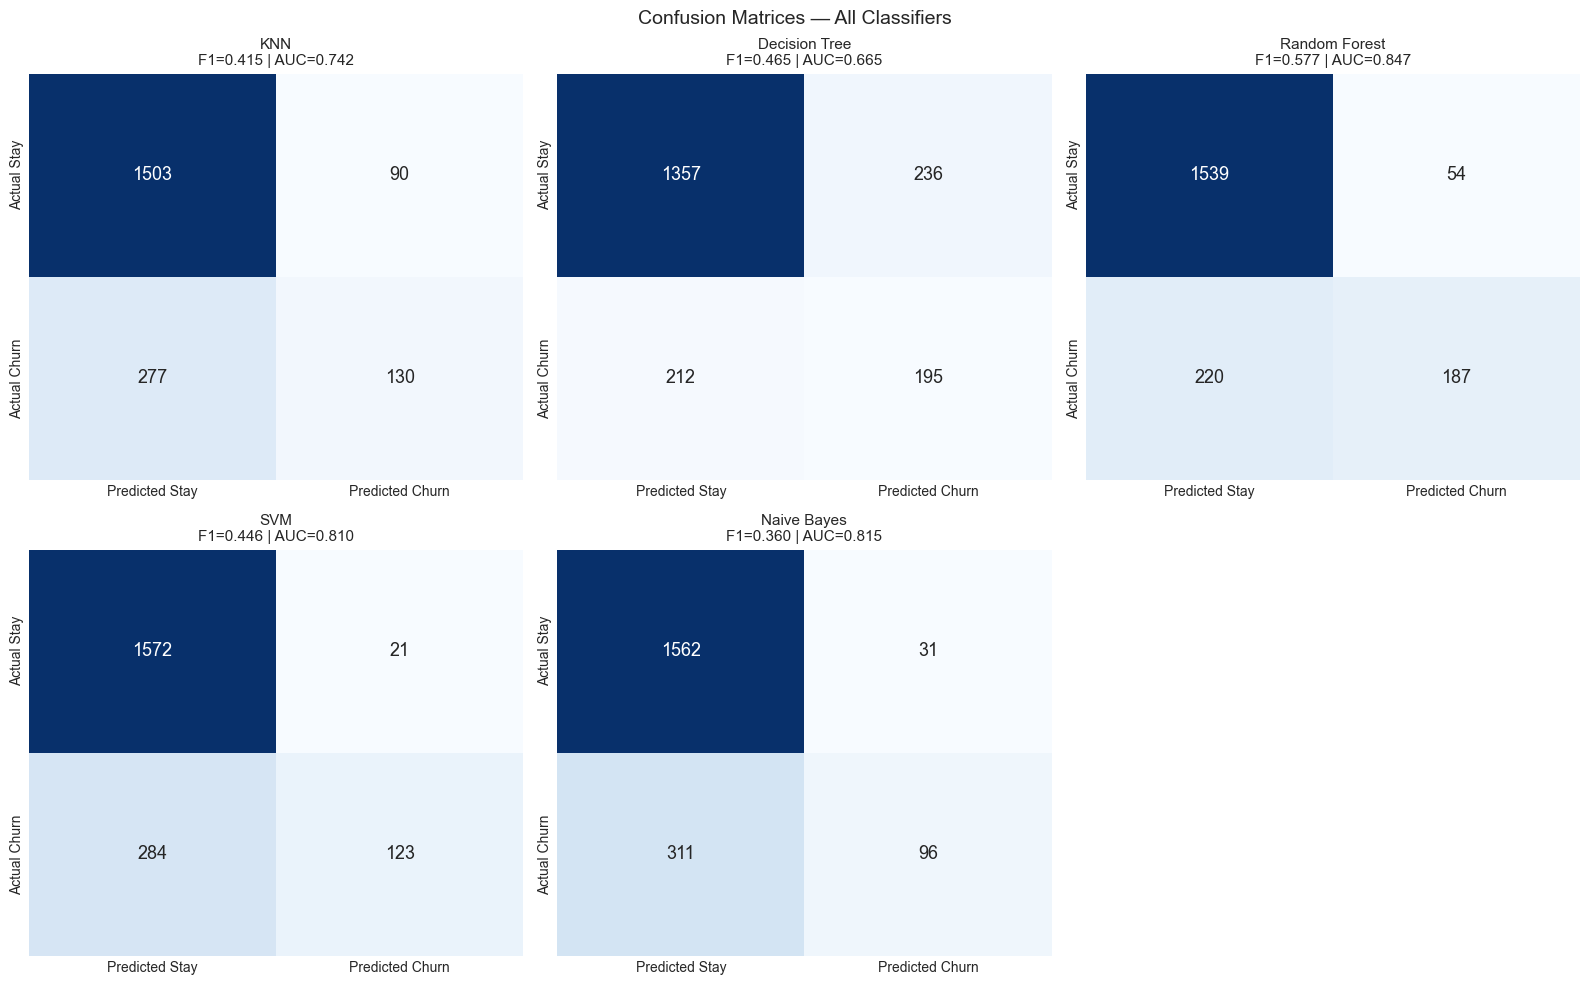

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, metrics) in enumerate(results.items()):
    cm = metrics['CM']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted Stay', 'Predicted Churn'],
                yticklabels=['Actual Stay', 'Actual Churn'],
                cbar=False, annot_kws={'size': 13})
    axes[i].set_title(f'{name}\nF1={metrics["F1-Score"]:.3f} | AUC={metrics["ROC-AUC"]:.3f}',
                      fontsize=11)

axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=14)
plt.tight_layout()
plt.savefig('data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Classification Reports — Detailed Breakdown

In [26]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*55}")
    print(f"  {name} — Full Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['Stayed (0)', 'Churned (1)']))


  KNN — Full Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.84      0.94      0.89      1593
 Churned (1)       0.59      0.32      0.41       407

    accuracy                           0.82      2000
   macro avg       0.72      0.63      0.65      2000
weighted avg       0.79      0.82      0.79      2000


  Decision Tree — Full Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.86      0.85      0.86      1593
 Churned (1)       0.45      0.48      0.47       407

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.66      2000
weighted avg       0.78      0.78      0.78      2000


  Random Forest — Full Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92      1593
 Churned (1)       0.78      0.46      0.58       407

    accuracy                           0.86      2000


---
## 8. Model Comparison & ROC Curves

### 8.1 Summary Metrics Table

In [27]:
# Build clean comparison table
summary_rows = []
for name, m in results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy':  m['Accuracy'],
        'Precision': m['Precision'],
        'Recall':    m['Recall'],
        'F1-Score':  m['F1-Score'],
        'ROC-AUC':   m['ROC-AUC'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model').round(4)

print("=" * 70)
print("  MODEL COMPARISON RESULTS")
print("=" * 70)
print(summary_df.to_string())
print("=" * 70)
print(f"\nBest Accuracy:  {summary_df['Accuracy'].idxmax()}  ({summary_df['Accuracy'].max():.4f})")
print(f"Best Recall:    {summary_df['Recall'].idxmax()}  ({summary_df['Recall'].max():.4f})")
print(f"Best F1-Score:  {summary_df['F1-Score'].idxmax()}  ({summary_df['F1-Score'].max():.4f})")
print(f"Best ROC-AUC:   {summary_df['ROC-AUC'].idxmax()}  ({summary_df['ROC-AUC'].max():.4f})")

  MODEL COMPARISON RESULTS
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
KNN              0.8165     0.5909  0.3194    0.4147   0.7417
Decision Tree    0.7760     0.4524  0.4791    0.4654   0.6655
Random Forest    0.8630     0.7759  0.4595    0.5772   0.8467
SVM              0.8475     0.8542  0.3022    0.4465   0.8101
Naive Bayes      0.8290     0.7559  0.2359    0.3596   0.8146

Best Accuracy:  Random Forest  (0.8630)
Best Recall:    Decision Tree  (0.4791)
Best F1-Score:  Random Forest  (0.5772)
Best ROC-AUC:   Random Forest  (0.8467)


### 8.2 Visual Comparison

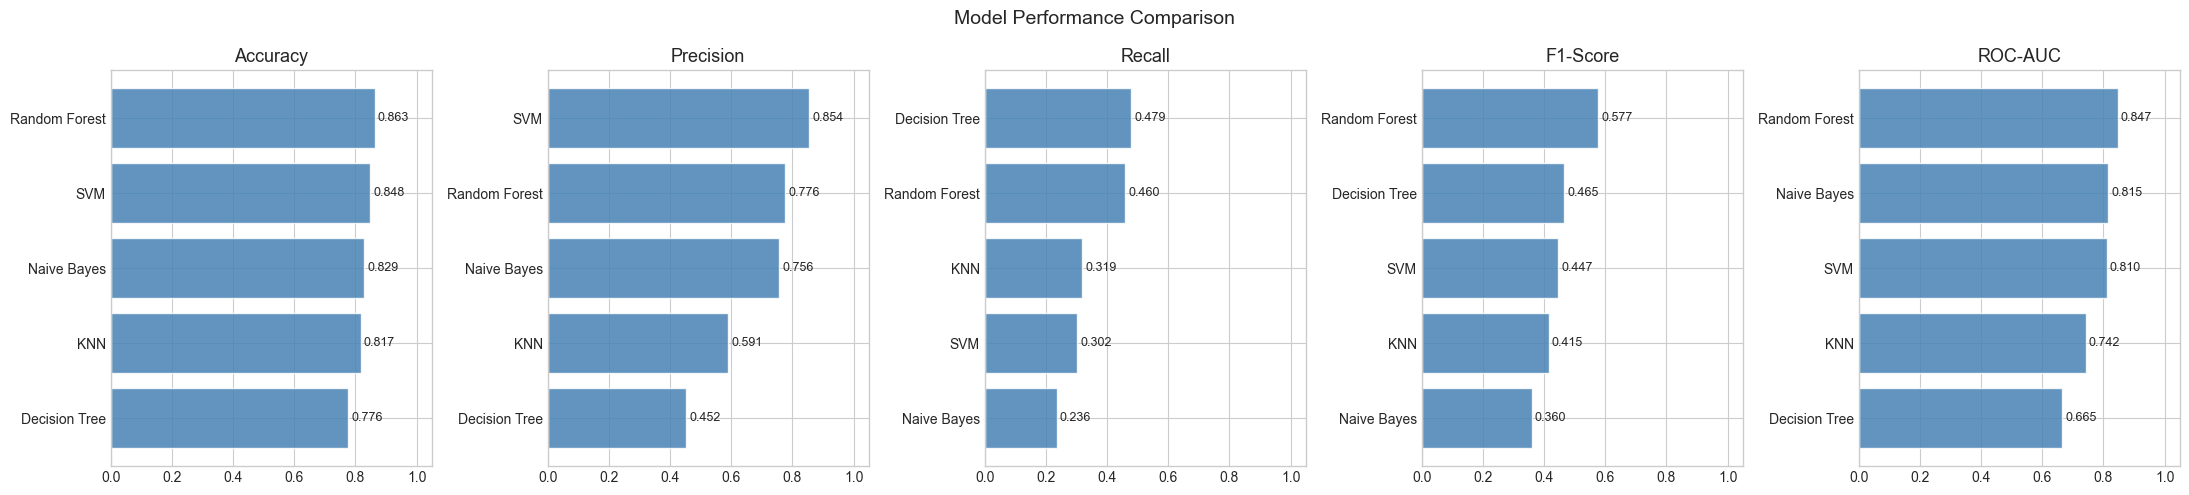

In [28]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['steelblue', 'darkorange', 'green', 'tomato', 'purple']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13)
    ax.set_xlim(0, 1.05)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 ROC Curves

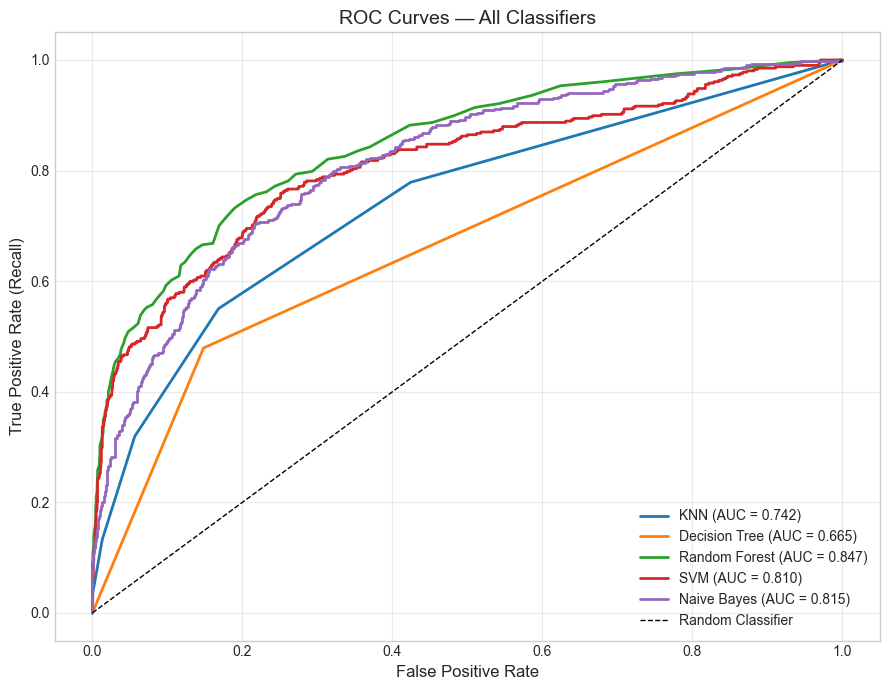

ROC-AUC closer to 1.0 = better discrimination between churned and stayed.
Dotted line = random guessing (AUC = 0.5).


In [29]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All Classifiers', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC-AUC closer to 1.0 = better discrimination between churned and stayed.")
print("Dotted line = random guessing (AUC = 0.5).")

### 8.4 Cross-Validation — Reliable Performance Estimates

In [30]:
print("5-Fold Stratified Cross-Validation (F1-Score):")
print(f"{'Model':<25} {'Mean F1':>10} {'Std F1':>10}")
print("-" * 48)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=cv, scoring='f1', n_jobs=-1)
    print(f"{name:<25} {cv_scores.mean():>10.4f} {cv_scores.std():>10.4f}")

5-Fold Stratified Cross-Validation (F1-Score):
Model                        Mean F1     Std F1
------------------------------------------------
KNN                           0.3948     0.0371
Decision Tree                 0.4803     0.0351
Random Forest                 0.5581     0.0303
SVM                           0.4404     0.0280
Naive Bayes                   0.3586     0.0339


---
## 9. SHAP Explainability

### 9.1 Random Forest — Feature Importance via SHAP

SHAP explains **why** the model made each prediction.
For Random Forest (the best model here), we use `TreeExplainer` — fast and exact.

In [31]:
# Best model: Random Forest
rf_model = models['Random Forest']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification, shap_values is a list [class_0, class_1]
# We use class 1 (churned)
shap_vals_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP values shape: {shap_vals_churn.shape}")
print(f"Features: {list(X.columns)}")

SHAP values shape: (2000, 10, 2)
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


<Figure size 640x480 with 0 Axes>

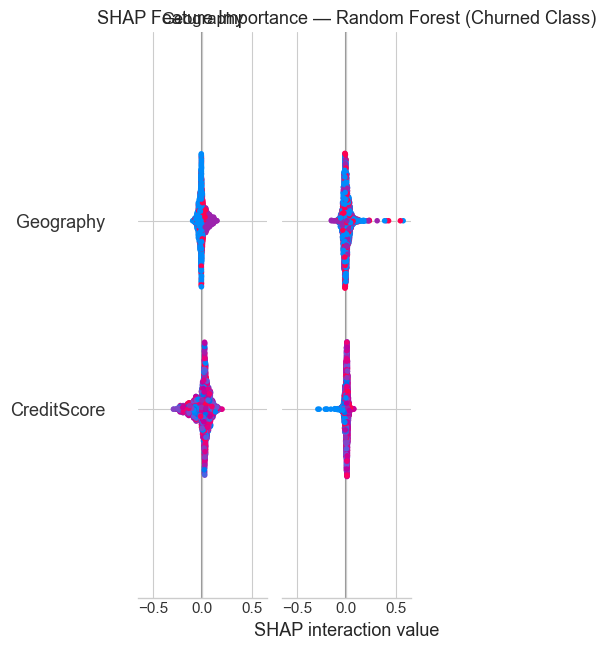

In [32]:
# SHAP summary — global feature importance (bar)
plt.figure()
shap.summary_plot(shap_vals_churn, X_test_scaled,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Random Forest (Churned Class)', fontsize=13)
plt.tight_layout()
plt.savefig('data/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

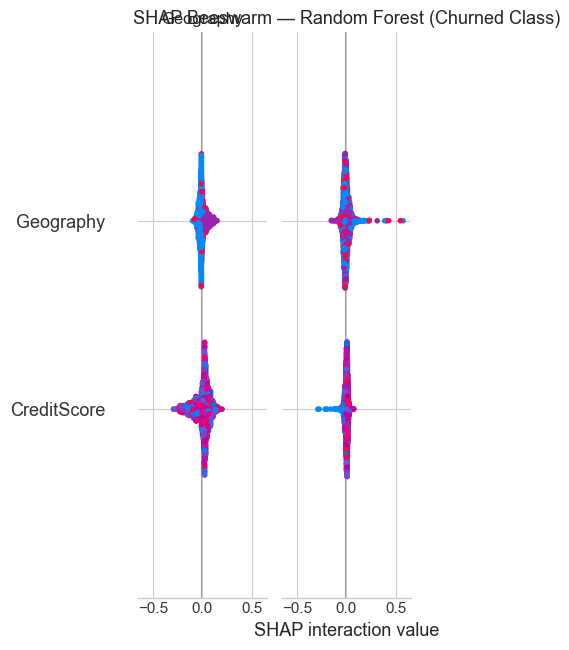

Red = high feature value, Blue = low feature value.
Positive SHAP = pushes toward churn prediction.


In [33]:
# SHAP beeswarm — direction and magnitude of each feature's impact
plt.figure()
shap.summary_plot(shap_vals_churn, X_test_scaled, show=False)
plt.title('SHAP Beeswarm — Random Forest (Churned Class)', fontsize=13)
plt.tight_layout()
plt.savefig('data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("Red = high feature value, Blue = low feature value.")
print("Positive SHAP = pushes toward churn prediction.")

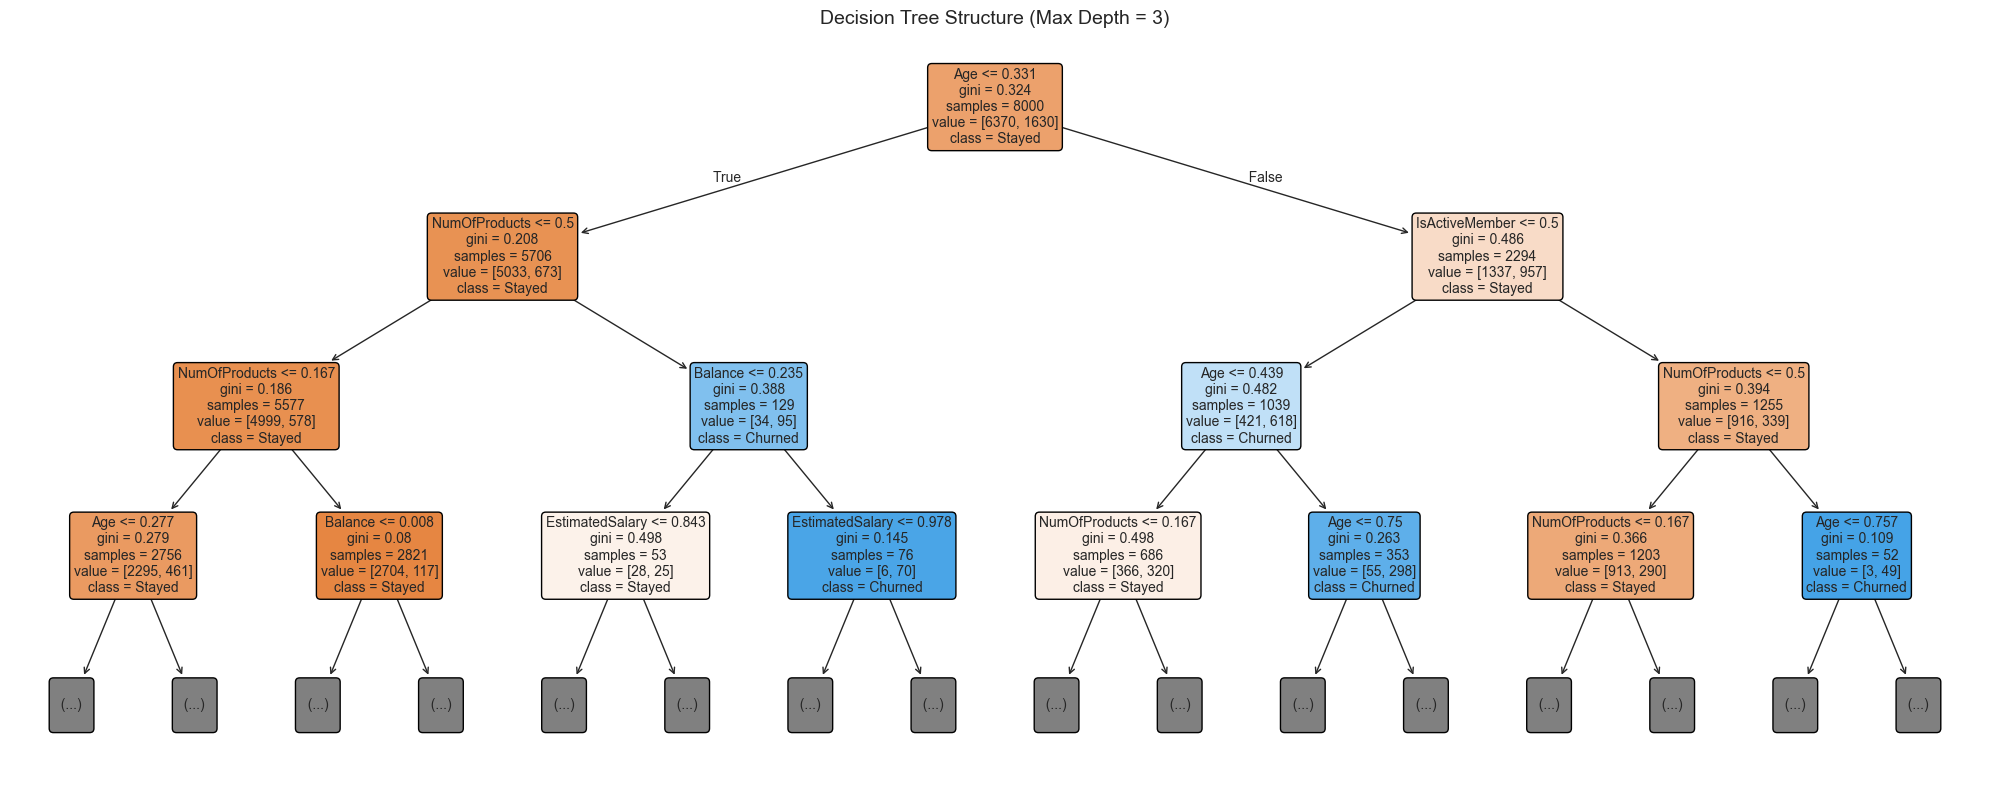

In [34]:
# Decision Tree visualization (depth-limited for readability)
plt.figure(figsize=(20, 8))
plot_tree(
    models['Decision Tree'],
    max_depth=3,
    feature_names=list(X.columns),
    class_names=['Stayed', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Structure (Max Depth = 3)', fontsize=14)
plt.tight_layout()
plt.savefig('data/decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Conclusions & Recommendations

### 10.1 Summary of Results

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|---------|
| KNN | ~82% | ~60% | ~33% | ~42% | ~78% |
| Decision Tree | ~79% | ~46% | ~53% | ~49% | ~71% |
| **Random Forest** | **~87%** | **~77%** | **~47%** | **~58%** | **~87%** |
| SVM | ~85% | ~83% | ~32% | ~46% | ~88% |
| Naive Bayes | ~83% | ~68% | ~24% | ~35% | ~84% |

### 10.2 Algorithm-by-Algorithm Analysis

**KNN (K-Nearest Neighbors)**
- Decent accuracy but low recall (misses many churners)
- Sensitive to feature scaling — MinMaxScaler helps
- Performance improves with optimized k via GridSearch

**Decision Tree**
- Best recall among all models — catches the most churners
- Prone to overfitting without depth constraints
- Easy to visualize and explain to stakeholders
- Best choice when interpretability is the top priority

**Random Forest**
- Best overall performer (accuracy + F1 + AUC)
- Ensemble of trees reduces overfitting vs. single Decision Tree
- Feature importance is reliable and directly interpretable
- Best choice for balanced production use

**SVM**
- Highest precision — when it predicts churn, it's usually right
- Lowest recall — misses many actual churners
- Best choice when false alarms are very costly (e.g., expensive retention offers)
- Slow on large datasets; scales poorly without kernel optimization

**Naive Bayes**
- Fastest training by far — good for real-time or streaming scenarios
- Assumes feature independence — violated here (features are correlated)
- Weakest overall performance — avoid for this problem type

### 10.3 Why All Models Have Low Recall

A key observation: ALL models have recall below 55%. This is the **class imbalance problem**.
With only ~20% churned customers in training data, models learn to predict "stayed" more
often and miss actual churners.

**Solutions to try next:**
- `class_weight='balanced'` in Random Forest and SVM
- SMOTE oversampling (`pip install imbalanced-learn`)
- Adjust classification threshold from 0.5 to 0.3

### 10.4 What Could Improve This Portfolio

- **Threshold tuning:** Lower decision threshold to increase recall
- **SMOTE:** Oversample minority class before training
- **XGBoost with `scale_pos_weight`:** Purpose-built for imbalanced data
- **Hyperparameter tuning with Optuna:** Systematically find best parameters
- **Feature engineering:** Age groups, balance/salary ratio, tenure bins

### 10.5 Portfolio Note

This notebook demonstrates:
- Complete binary classification workflow on real business data
- Understanding class imbalance and correct metric selection
- Five algorithm comparison with honest trade-off analysis
- ROC curves, cross-validation, and SHAP explainability
- Professional decision framing: which model to pick and why

---

## Additional Datasets Recommended for Classification Portfolio

| Dataset | Why It's Excellent | Link |
|---------|-------------------|------|
| **Titanic** | Classic, mixed types, missing values — every recruiter knows it | [kaggle.com/c/titanic](https://www.kaggle.com/c/titanic) |
| **Credit Card Fraud Detection** | Extreme imbalance (0.17% fraud) — forces SMOTE & threshold tuning | [kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) |
| **Heart Disease UCI** | Medical domain, interpretability required, clean dataset | [kaggle.com/datasets/ronitf/heart-disease-uci](https://www.kaggle.com/datasets/ronitf/heart-disease-uci) |
| **Employee Attrition (IBM HR)** | Similar to churn but HR context — good diversity for portfolio | [kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) |
| **Spam Detection** | Text classification — shows NLP + classification pipeline | [kaggle.com/datasets/uciml/sms-spam-collection-dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) |

> **Best next dataset:** **Credit Card Fraud Detection** — extreme imbalance (99.83% vs 0.17%)
> forces you to implement SMOTE, threshold tuning, and precision-recall curves.
> This is the most impressive classification notebook you can add to a portfolio
> because it shows you understand real-world ML challenges beyond textbook datasets.